# SNOTEL Lib Demo (Metloom Client)

This notebook demonstrates how to use the `snotel_lib` to fetch and cache SNOTEL data.

In [1]:
import datetime as dt
import logging

import matplotlib.pyplot as plt

from snotel_lib import MetloomClient

logging.basicConfig(level=logging.INFO, force=True)


client = MetloomClient()

## 1. Fetch Metadata
This will download `all_stations.geojson` to your cache on the first run.

In [2]:
metadata = client.get_stations_metadata(force_update=True)
metadata.head()

INFO:snotel_lib.clients.metloom_client:Delegating metadata fetch to EgagliClient (fast GeoJSON index).
INFO:snotel_lib.clients.egagli_client:Fetching metadata from internet: https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson
INFO:snotel_lib.clients.egagli_client:Metadata retrieval took 0.29s (cache miss, 1060 stations)


,station_id,station_name,network,elevation_m,latitude,longitude,state,huc,mgrs,mountain_range,begin_date,end_date,csv_data,geometry
0,301_CA_SNTL,Adin Mtn,SNOTEL,1886.712036,41.235828,-120.791924,California,180200021403,10TFL,Great Basin Ranges,1983-10-01,2026-03-12,True,POINT (-120.79192 41.23583)
1,907_UT_SNTL,Agua Canyon,SNOTEL,2712.719971,37.522171,-112.271179,Utah,160300020301,12SUG,Colorado Plateau,1994-10-01,2026-03-12,True,POINT (-112.27118 37.52217)
2,916_MT_SNTL,Albro Lake,SNOTEL,2529.840088,45.597229,-111.959023,Montana,100200050701,12TVR,Central Montana Rocky Mountains,1996-09-01,2026-03-12,True,POINT (-111.95902 45.59723)
3,1267_AK_SNTL,Alexander Lake,SNOTEL,48.768002,61.749668,-150.889664,Alaska,190205051106,05VPJ,None,2014-08-28,2026-03-12,True,POINT (-150.88966 61.74967)
4,908_WA_SNTL,Alpine Meadows,SNOTEL,1066.800049,47.779572,-121.698471,Washington,171100100501,10TET,Cascade Range,1994-09-01,2026-03-12,True,POINT (-121.69847 47.77957)


## 2. Fetch Station Data
Let's fetch data for a specific station, e.g., '679_WA_SNTL' (Paradise, WA, at Mount Rainier).

In [3]:
today_str = dt.datetime.now().strftime("%Y-%m-%d")
df = client.get_station_data("679:WA:SNTL", start_date="2010-10-01", end_date=today_str, force_update=True)
df.tail()

INFO:snotel_lib.clients.metloom_client:Fetching metloom data for 679:WA:SNTL...
INFO:snotel_lib.clients.metloom_client:Data retrieval for 679:WA:SNTL took 7.08s (cache miss, 5642 rows)


datetime,swe_m,snow_depth_m,precip_m,tavg_c,tmin_c,tmax_c
date,f32,f32,f32,f32,f32,f32
2026-03-08,0.66802,1.7018,0.03302,-1.1,-6.7,1.7
2026-03-09,0.6731,1.5748,0.01524,-6.5,-8.4,-4.0
2026-03-10,0.68834,1.8288,0.0127,-6.2,-9.1,-2.3
2026-03-11,0.70104,1.9812,0.07874,-2.0,-5.1,1.3
2026-03-12,0.77978,2.2352,null,null,null,null


## 3. Visualize
Quick plot of Snow Water Equivalent (SWE) and Snow Depth together

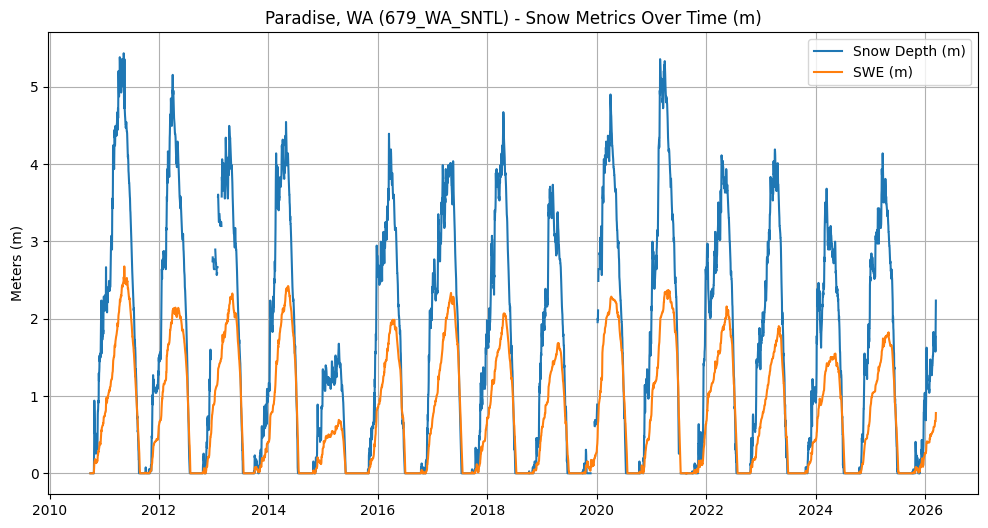

In [4]:
logging.basicConfig(level=logging.INFO, force=True)
plt.figure(figsize=(12, 6))
plt.plot(df["datetime"], df["snow_depth_m"], label="Snow Depth (m)")
plt.plot(df["datetime"], df["swe_m"], label="SWE (m)")

plt.title("Paradise, WA (679_WA_SNTL) - Snow Metrics Over Time (m)")
plt.ylabel("Meters (m)")
plt.grid(True)
plt.legend()
plt.show()